In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("updated_cleaned_dataset.csv")

In [4]:
df.head()

,text,label,label_encoded
0,vegetable oil,halal,0
1,beef stock contains less than of mirepoix carr...,halal,0
2,clam stock potatoes clams cream vegetable oil ...,haram,1
3,water cream broccoli celery vegetable oil corn...,haram,1
4,chicken stock contains less than of yeast extr...,halal,0


In [11]:
X=df['text']
y=df['label_encoded']

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [16]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [27]:
y_pred = model.predict(X_test_tfidf)

In [21]:
results = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": y_pred
})

print(results.head(10))

                                                    text  actual  predicted
5557   pepperoni stick beef pork water salt contains ...       1          1
6361   cooked scallop trim meat sorbitol fish sauce s...       1          1
21701  fresh cucumbers fructose water salt vinegar mu...       0          0
11873                                    organic mangoes       0          0
4217   pork non fat dry milk sea salt contains less t...       1          1
17034     extra virgin olive oil soy lecithin propellant       0          0
29303  water dried cane syrup rice flour eggs palm oi...       1          1
27166  reduced fat mozzarella cheese pasteurized part...       1          1
26278  wheat flour sugar vegetable oil palm oil sunfl...       1          1
29699  organic spinach organic unbleached wheat flour...       1          0


In [22]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8634238787113077

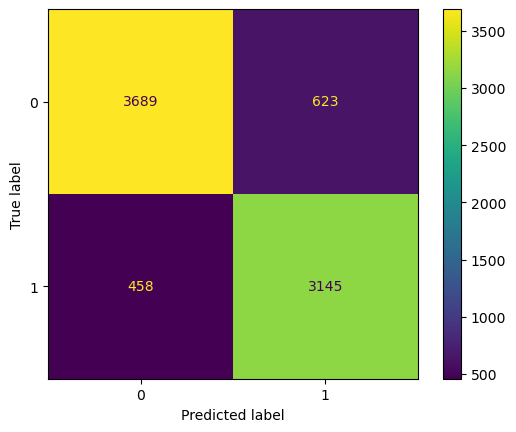

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.86      0.87      4312
           1       0.83      0.87      0.85      3603

    accuracy                           0.86      7915
   macro avg       0.86      0.86      0.86      7915
weighted avg       0.86      0.86      0.86      7915



AUC: 0.9349711215195335


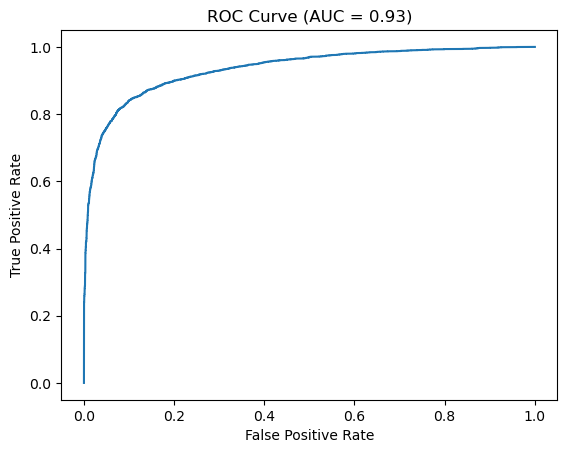

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test_tfidf)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.2f})")
plt.show()